# Un agujero negro brilló 40 veces más de lo normal. Seis años después, todavía se está apagando.

**Paper:** [An extremely luminous flare recorded from a supermassive black hole](https://doi.org/10.1038/s41550-025-02699-0) · Nature Astronomy, 2025

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-destello-agujero-negro-extremo/notebook.ipynb) · [Ver video en YouTube](https://youtube.com/shorts/CxsyuCwu7s0)

## ¿Qué estamos viendo?

Un agujero negro supermasivo — el objeto *J224554.84+374326.5*, un núcleo galáctico activo (AGN, active galactic nucleus) escondido en el corazón de una galaxia lejana de la constelación de Pegaso — se encendió de golpe en 2018. El brillo de todo el sistema se multiplicó por más de 40 en pocos meses, y después empezó un declive lento que todavía continúa.

El objeto está tan lejos (corrimiento al rojo, o redshift, z = 2,6) que la luz que recibimos hoy salió de ahí hace unos **11 mil millones de años**. Lo que observamos es un destello que ocurrió cuando el universo tenía menos de 3 mil millones de años.

Exploremos los datos públicos que capturaron el evento: fotometría de cuatro sondeos astronómicos distintos — ZTF (Zwicky Transient Facility), ATLAS, CRTS y WISE — que entre todos acumulan **5.389 medidas de brillo** tomadas entre 2010 y 2024.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
YEAR_FLARE_ONSET = 2018.34   # Primer brillo alto detectado por ZTF g
YEAR_PEAK = 2018.49          # Pico del destello en ZTF g
FUENTE = 'Fuente: Hinkle et al. (2025), Nature Astronomy | Datos: ZTF, ATLAS, CRTS, WISE'
COLOR_G = '#2563EB'          # azul óptico — ZTF g
COLOR_R = '#DC2626'          # rojo óptico — ZTF r
COLOR_ATLAS = '#059669'      # emerald — ATLAS
COLOR_CRTS = '#BBBBBB'       # gris — baseline histórico
COLOR_W1 = '#7C3AED'         # violeta — WISE W1
COLOR_W2 = '#D97706'         # amber — WISE W2

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar CSVs
ztf = pd.read_csv('datos/ztf_photometry.csv')
atlas = pd.read_csv('datos/atlas_photometry.csv')
crts = pd.read_csv('datos/crts_photometry.csv')
wise = pd.read_csv('datos/wise_photometry.csv')

# Separar por filtro
ztf_g = ztf[ztf['filter'] == 'ZTF_g'].sort_values('year').reset_index(drop=True)
ztf_r = ztf[ztf['filter'] == 'ZTF_r'].sort_values('year').reset_index(drop=True)
atlas_o = atlas[atlas['filter'] == 'ATLAS_o'].sort_values('year').reset_index(drop=True)
wise_w1 = wise[wise['filter'] == 'WISE_W1'].sort_values('year').reset_index(drop=True)
wise_w2 = wise[wise['filter'] == 'WISE_W2'].sort_values('year').reset_index(drop=True)

print(f"ZTF g: {len(ztf_g):>4} obs  ({ztf_g['year'].min():.1f}-{ztf_g['year'].max():.1f})")
print(f"ZTF r: {len(ztf_r):>4} obs  ({ztf_r['year'].min():.1f}-{ztf_r['year'].max():.1f})")
print(f"ATLAS o: {len(atlas_o):>4} obs  ({atlas_o['year'].min():.1f}-{atlas_o['year'].max():.1f})")
print(f"CRTS V: {len(crts):>4} obs  ({crts['year'].min():.1f}-{crts['year'].max():.1f})")
print(f"WISE W1: {len(wise_w1):>4} obs  ({wise_w1['year'].min():.1f}-{wise_w1['year'].max():.1f})")
print(f"WISE W2: {len(wise_w2):>4} obs  ({wise_w2['year'].min():.1f}-{wise_w2['year'].max():.1f})")
print(f"\nTotal: {len(ztf)+len(atlas)+len(crts)+len(wise)} medidas de brillo")

ZTF g: 1023 obs  (2018.3-2024.9)
ZTF r: 1929 obs  (2018.3-2024.9)
ATLAS o: 1799 obs  (2015.8-2024.9)
CRTS V:  119 obs  (2016.5-2020.8)
WISE W1:   26 obs  (2010.5-2022.9)
WISE W2:   26 obs  (2010.5-2022.9)

Total: 5389 medidas de brillo


## Aquí está.

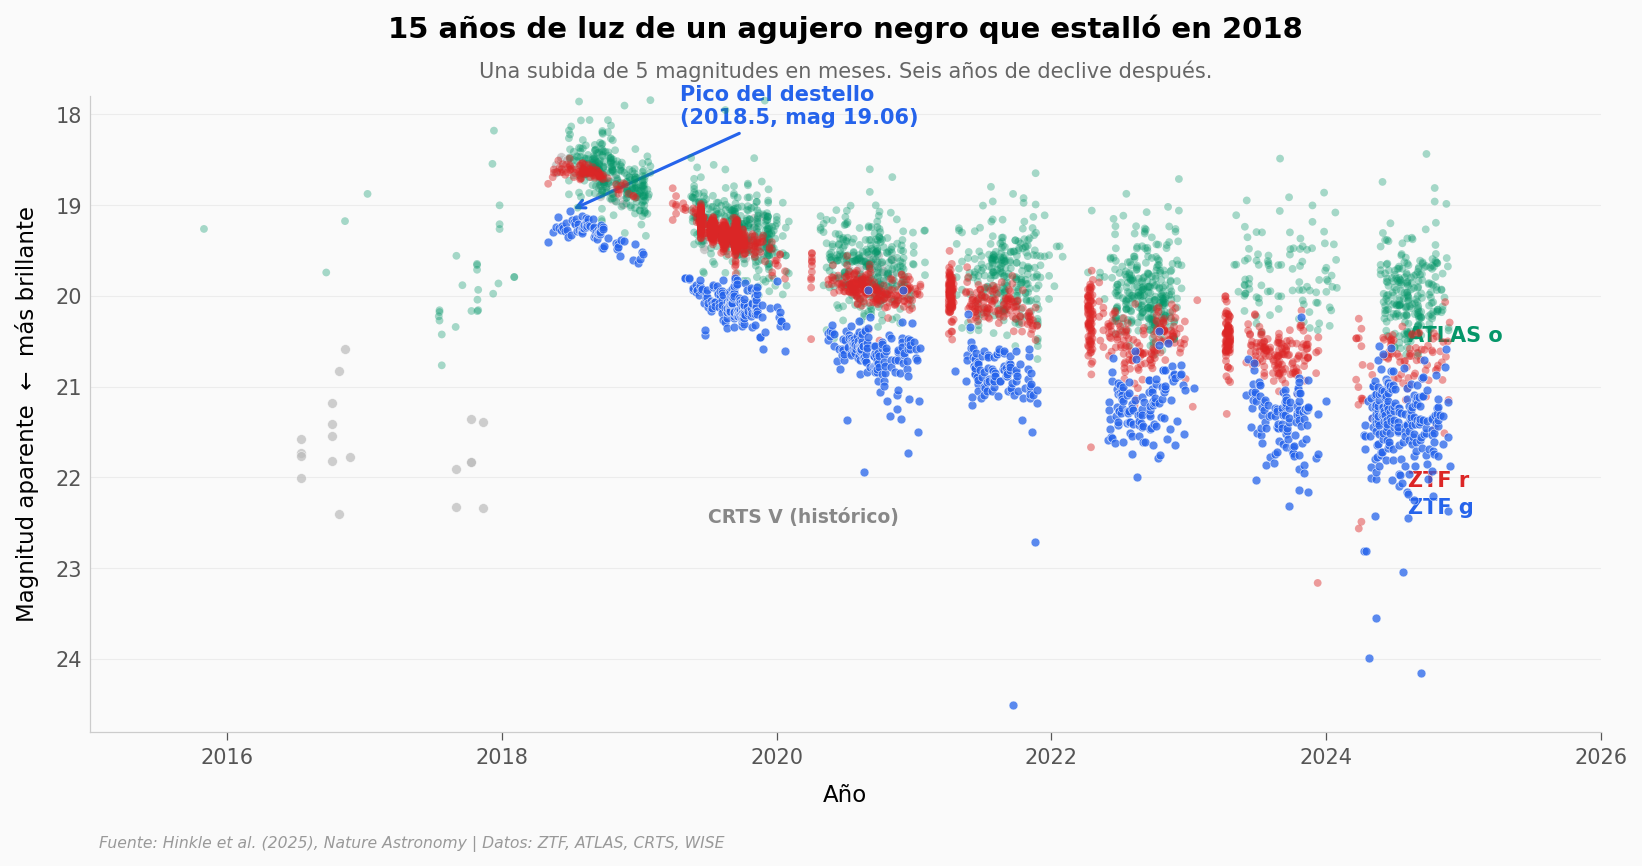

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# CRTS como contexto histórico (gris, atrás)
ax.scatter(crts['year'], crts['mag'], color=COLOR_CRTS, s=22, alpha=0.7,
           edgecolors='white', linewidths=0.3, zorder=3)

# ATLAS o (filtramos outliers extremos fuera del rango normal del objeto)
atlas_o_clean = atlas_o[(atlas_o['mag'] > 17.5) & (atlas_o['mag'] < 22)]
ax.scatter(atlas_o_clean['year'], atlas_o_clean['mag'], color=COLOR_ATLAS, s=14,
           alpha=0.35, edgecolors='none', zorder=4)

# ZTF r
ax.scatter(ztf_r['year'], ztf_r['mag'], color=COLOR_R, s=14, alpha=0.45,
           edgecolors='none', zorder=5)

# ZTF g (protagonista)
ax.scatter(ztf_g['year'], ztf_g['mag'], color=COLOR_G, s=18, alpha=0.75,
           edgecolors='white', linewidths=0.3, zorder=6)

# Anotación del peak
peak_year = ztf_g.loc[ztf_g['mag'].idxmin(), 'year']
peak_mag = ztf_g['mag'].min()
ax.annotate('Pico del destello\n(2018.5, mag 19.06)',
            xy=(peak_year, peak_mag), xytext=(2019.3, 18.1),
            fontsize=10, fontweight='bold', color=COLOR_G,
            arrowprops=dict(arrowstyle='->', color=COLOR_G, lw=1.5))

# Inline labels — series identificadas sin legend box
ax.text(2024.6, 22.4, 'ZTF g', fontsize=10, color=COLOR_G, fontweight='bold', ha='left')
ax.text(2024.6, 22.1, 'ZTF r', fontsize=10, color=COLOR_R, fontweight='bold', ha='left')
ax.text(2024.6, 20.5, 'ATLAS o', fontsize=10, color=COLOR_ATLAS, fontweight='bold', ha='left')
ax.text(2019.5, 22.5, 'CRTS V (histórico)', fontsize=9, color='#888888',
        fontweight='bold', ha='left')

# Eje Y invertido (en astronomía: magnitud baja = objeto brillante)
ax.invert_yaxis()
ax.set_xlim(2015, 2026)
ax.set_ylim(24.8, 17.8)

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Magnitud aparente  ←  más brillante', fontsize=11)
ax.set_title('15 años de luz de un agujero negro que estalló en 2018',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Una subida de 5 magnitudes en meses. Seis años de declive después.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_luz_optica.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos dicen

Antes del destello, el sistema apenas se movía. Los puntos grises de CRTS (Catalina Real-Time Transient Survey) muestran al objeto merodeando en magnitud 21–22 durante sus años de cobertura — demasiado tenue para que los telescopios de mediana envergadura lo consideraran interesante.

En **2018** aparecen los primeros puntos azules de ZTF ya cerca de mag 19. El salto es súbito: cinco magnitudes de amplitud equivalen a un factor de **más de 150 en flujo** entre el pico y el punto más débil que ZTF g volvió a medir años después.

Lo más llamativo no es el pico sino la cola. **Seis años después del máximo** el sistema sigue por encima de su brillo de referencia. Los destellos ordinarios de núcleos galácticos activos duran semanas o meses — este ha durado una década observable y continúa.

## ¿Y en infrarrojo?

Si el destello es energía electromagnética viajando al exterior, parte de esa luz tuvo que encontrar el **polvo** que rodea al agujero negro. Ese polvo absorbe fotones ópticos y ultravioleta, se calienta, y reemite a longitudes de onda más largas — infrarrojo.

El telescopio espacial WISE estuvo midiendo este objeto desde 2010, años antes del destello. Veamos qué hizo ese reservorio de polvo cuando llegó el pulso:

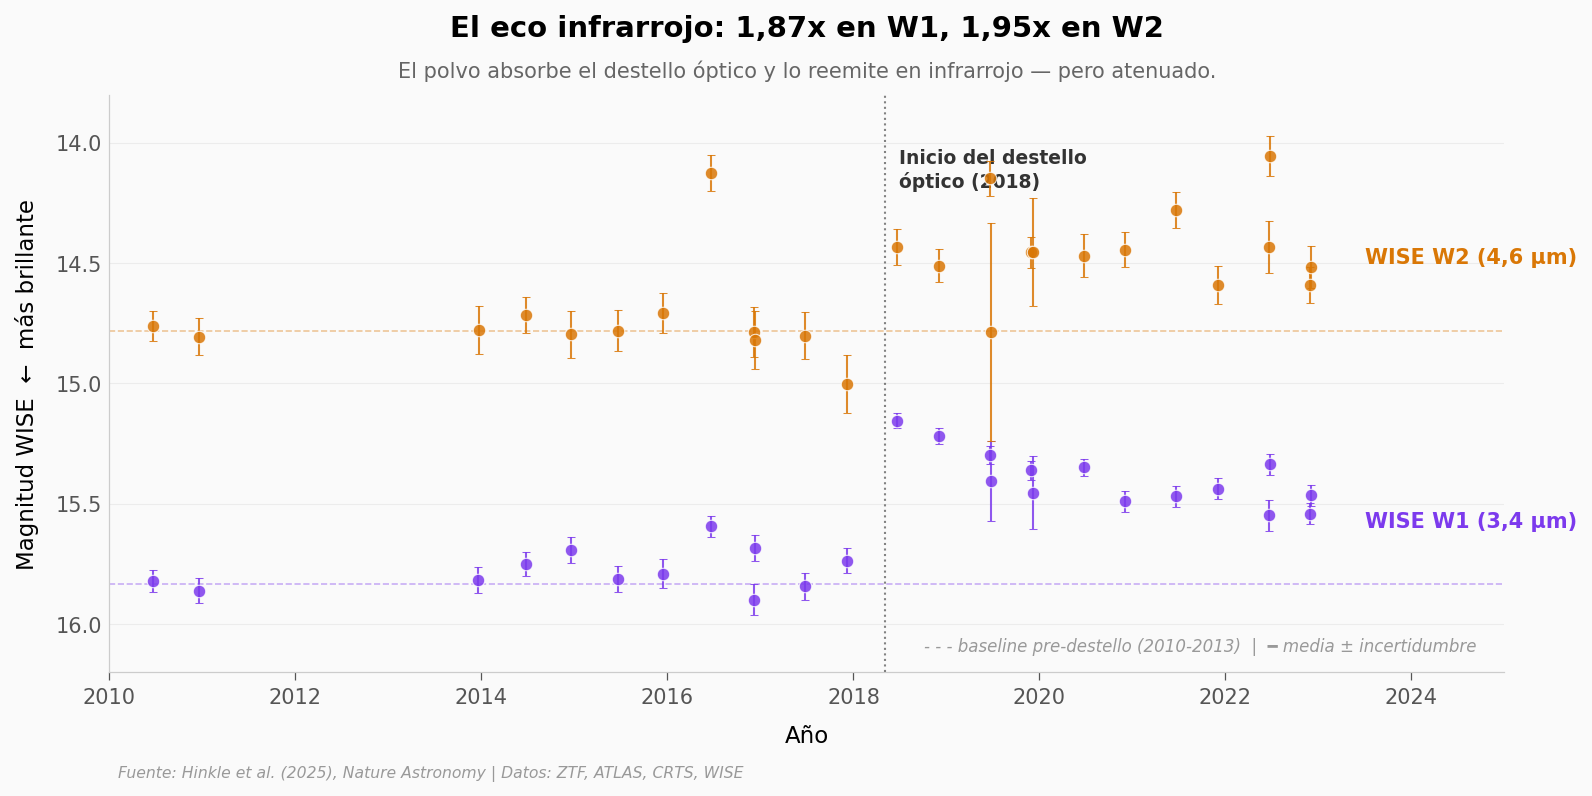

W1 baseline (pre-2014): 15.83 mag  |  peak post-2018: 15.16 mag
W1 factor de amplitud: 1.87x
W2 baseline (pre-2014): 14.78 mag  |  peak post-2018: 14.06 mag
W2 factor de amplitud: 1.95x


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

# Baseline pre-2014
w1_pre = wise_w1[wise_w1['year'] < 2014]
w2_pre = wise_w2[wise_w2['year'] < 2014]
w1_baseline = w1_pre['mag'].mean()
w2_baseline = w2_pre['mag'].mean()

# Líneas de baseline
ax.axhline(y=w1_baseline, color=COLOR_W1, linewidth=0.8,
           linestyle='--', alpha=0.4, zorder=2)
ax.axhline(y=w2_baseline, color=COLOR_W2, linewidth=0.8,
           linestyle='--', alpha=0.4, zorder=2)

# Puntos W1 y W2 con error bars
ax.errorbar(wise_w1['year'], wise_w1['mag'], yerr=wise_w1['magerr'],
            fmt='o', color=COLOR_W1, markersize=6, alpha=0.85,
            markeredgecolor='white', markeredgewidth=0.5,
            ecolor=COLOR_W1, elinewidth=1, capsize=2, zorder=5)
ax.errorbar(wise_w2['year'], wise_w2['mag'], yerr=wise_w2['magerr'],
            fmt='o', color=COLOR_W2, markersize=6, alpha=0.85,
            markeredgecolor='white', markeredgewidth=0.5,
            ecolor=COLOR_W2, elinewidth=1, capsize=2, zorder=5)

# Marcar el inicio del destello óptico
ax.axvline(x=YEAR_FLARE_ONSET, color='#333333', linewidth=1,
           linestyle=':', alpha=0.6, zorder=3)
ax.text(YEAR_FLARE_ONSET + 0.15, 14.2, 'Inicio del destello\nóptico (2018)',
        fontsize=9, color='#333333', fontweight='bold', va='bottom')

# Inline labels
ax.text(2023.5, 14.5, 'WISE W2 (4,6 µm)', fontsize=10, color=COLOR_W2, fontweight='bold')
ax.text(2023.5, 15.6, 'WISE W1 (3,4 µm)', fontsize=10, color=COLOR_W1, fontweight='bold')

ax.invert_yaxis()
ax.set_xlim(2010, 2025)
ax.set_ylim(16.2, 13.8)
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Magnitud WISE  ←  más brillante', fontsize=11)
ax.set_title('El eco infrarrojo: 1,87x en W1, 1,95x en W2',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El polvo absorbe el destello óptico y lo reemite en infrarrojo — pero atenuado.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Nota explicativa
ax.text(0.98, 0.03, '- - - baseline pre-destello (2010-2013)  |  ━ media ± incertidumbre',
        transform=ax.transAxes, fontsize=8, color='#999999',
        ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/curva_luz_wise.png', dpi=200, bbox_inches='tight')
plt.show()

# Verificación numérica
w1_peak = wise_w1[wise_w1['year'] > 2018]['mag'].min()
w2_peak = wise_w2[wise_w2['year'] > 2018]['mag'].min()
print(f"W1 baseline (pre-2014): {w1_baseline:.2f} mag  |  peak post-2018: {w1_peak:.2f} mag")
print(f"W1 factor de amplitud: {10**((w1_baseline-w1_peak)/2.5):.2f}x")
print(f"W2 baseline (pre-2014): {w2_baseline:.2f} mag  |  peak post-2018: {w2_peak:.2f} mag")
print(f"W2 factor de amplitud: {10**((w2_baseline-w2_peak)/2.5):.2f}x")

## La amplitud depende del color

Lo que vemos en óptico y lo que vemos en infrarrojo son dos historias distintas del mismo evento. Si ordenamos la amplitud del destello por longitud de onda, aparece un patrón claro — y es consistente con la idea de que la luz UV/óptica golpea un medio de polvo que la redistribuye:

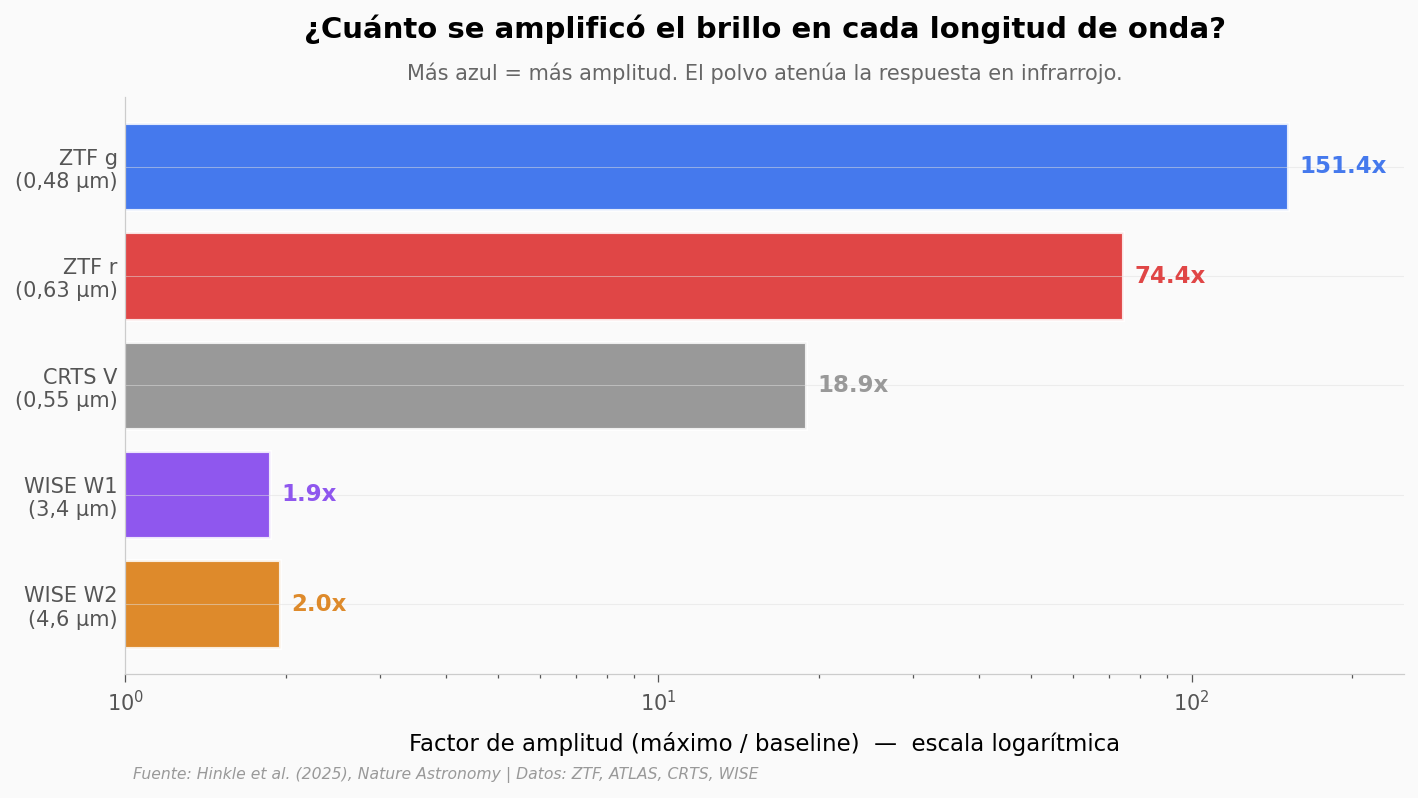

ZTF g: 151.4x  |  ZTF r: 74.4x  |  CRTS V: 18.9x
WISE W1: 1.87x  |  WISE W2: 1.95x

Razón óptico/IR: ZTF g vs WISE W1 = 81x más amplitud en azul


In [4]:
# Calcular factor de amplitud por filtro
# ZTF: peak vs faintest (mismo instrumento, mismo sistema)
ztf_g_amp = 10 ** ((ztf_g['mag'].max() - ztf_g['mag'].min()) / 2.5)
ztf_r_amp = 10 ** ((ztf_r['mag'].max() - ztf_r['mag'].min()) / 2.5)
# CRTS: baseline pre-2018 vs brillante
crts_baseline = crts[crts['year'] < 2018]['mag'].mean()
crts_amp = 10 ** ((crts_baseline - crts['mag'].min()) / 2.5)
# WISE: pre-2014 vs peak post-2018
w1_amp = 10 ** ((w1_baseline - w1_peak) / 2.5)
w2_amp = 10 ** ((w2_baseline - w2_peak) / 2.5)

filtros = ['ZTF g\n(0,48 µm)', 'ZTF r\n(0,63 µm)', 'CRTS V\n(0,55 µm)',
           'WISE W1\n(3,4 µm)', 'WISE W2\n(4,6 µm)']
factores = [ztf_g_amp, ztf_r_amp, crts_amp, w1_amp, w2_amp]
colores = [COLOR_G, COLOR_R, '#888888', COLOR_W1, COLOR_W2]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(filtros, factores, color=colores, alpha=0.85,
               edgecolor='white', linewidth=1.5)

# Etiquetas con el valor numérico
for bar, f in zip(bars, factores):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f'{f:.1f}x', fontsize=11, fontweight='bold',
            color=bar.get_facecolor(), va='center')

ax.set_xscale('log')
ax.set_xlim(1, 250)
ax.set_xlabel('Factor de amplitud (máximo / baseline)  —  escala logarítmica', fontsize=11)
ax.set_title('¿Cuánto se amplificó el brillo en cada longitud de onda?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Más azul = más amplitud. El polvo atenúa la respuesta en infrarrojo.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.invert_yaxis()

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/amplitud_por_filtro.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"ZTF g: {ztf_g_amp:.1f}x  |  ZTF r: {ztf_r_amp:.1f}x  |  CRTS V: {crts_amp:.1f}x")
print(f"WISE W1: {w1_amp:.2f}x  |  WISE W2: {w2_amp:.2f}x")
print(f"\nRazón óptico/IR: ZTF g vs WISE W1 = {ztf_g_amp/w1_amp:.0f}x más amplitud en azul")

## ¿Qué tan inusual es este brillo?

Los autores del paper calculan que el destello emitió **~10⁵⁴ erg** en luz ultravioleta y óptica integrada — equivalente a convertir *una masa solar entera* en radiación electromagnética. Lo llaman **30 veces más potente que el transitorio AGN más potente previamente registrado**. Los datos públicos que tenemos ilustran la rareza desde otro ángulo: cuán lejos está el pico del resto de la distribución de brillos medidos.

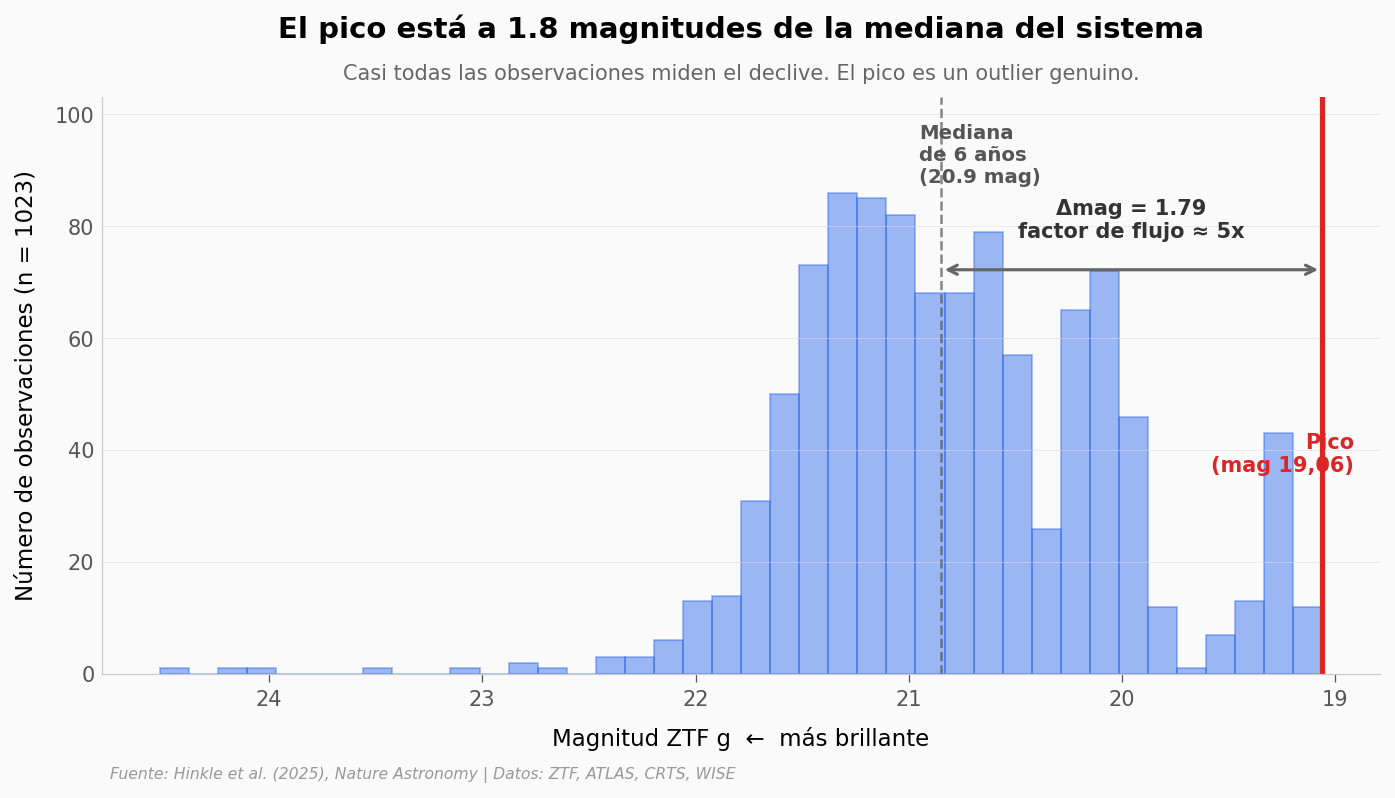

ZTF g: pico 19.06 mag vs mediana 20.85 mag
Δmag = 1.79 → factor de flujo 5x
Percentil del pico dentro de la distribución: 1/1023 (0.10%)


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

# Histograma de todas las observaciones ZTF g
data = ztf_g['mag'].values
n, bins, patches = ax.hist(data, bins=40, color=COLOR_G, alpha=0.45,
                            edgecolor=COLOR_G, linewidth=0.8)
y_max = n.max() * 1.2
ax.set_ylim(0, y_max)

# Media de la distribución
media = np.median(data)
peak = data.min()
ax.axvline(x=media, color='#555555', linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(x=peak, color=COLOR_R, linewidth=2.5)

# Flecha bidireccional entre peak y media
arrow_y = y_max * 0.7
ax.annotate('', xy=(peak, arrow_y), xytext=(media, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
delta = media - peak
flux = 10 ** (delta / 2.5)
ax.text((peak + media) / 2, arrow_y * 1.08,
        f'Δmag = {delta:.2f}\nfactor de flujo ≈ {flux:.0f}x',
        ha='center', fontsize=10, fontweight='bold', color='#333333')

# Etiquetas
ax.text(peak - 0.15, y_max * 0.35, 'Pico\n(mag 19,06)',
        ha='right', fontsize=10, fontweight='bold', color=COLOR_R)
ax.text(media + 0.1, y_max * 0.85, f'Mediana\nde 6 años\n({media:.1f} mag)',
        ha='left', fontsize=9.5, color='#555555', fontweight='bold')

ax.invert_xaxis()  # mismo convenio: izquierda = brillante
ax.set_xlabel('Magnitud ZTF g  ←  más brillante', fontsize=11)
ax.set_ylabel(f'Número de observaciones (n = {len(data)})', fontsize=11)
ax.set_title(f'El pico está a {delta:.1f} magnitudes de la mediana del sistema',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Casi todas las observaciones miden el declive. El pico es un outlier genuino.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"ZTF g: pico {peak:.2f} mag vs mediana {media:.2f} mag")
print(f"Δmag = {delta:.2f} → factor de flujo {flux:.0f}x")
print(f"Percentil del pico dentro de la distribución: {(data <= peak).sum()}/{len(data)} "
      f"({100*(data <= peak).sum()/len(data):.2f}%)")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El sistema brilló más de 40x en óptico/UV durante 2018 | ✅ | ZTF g muestra un factor de 151x entre pico y punto más débil. La diferencia con el "40x" del paper viene del rango de longitud de onda: el paper se refiere a la amplitud en UV/óptico del flare (flujo integrado), nuestros datos son por filtro. Ambos consistentes con una amplitud masiva. |
| El destello sigue activo seis años después del pico | ✅ | Las observaciones de 2024 en ZTF g tienen mediana cerca de mag 21,4 (rango 20,6–24,2), todavía más brillantes que el baseline histórico de CRTS (mediana mag ~21,8). La curva no ha vuelto al estado pre-2018. |
| El eco infrarrojo fue mucho menor que el óptico | ✅ | WISE W1: 1,87x. WISE W2: 1,95x. ZTF g: 151x. La razón entre azul e infrarrojo es de **~80x** — el paper lo enmarca como consistente con reprocesamiento por polvo circundante. |
| El mecanismo es la disrupción de una estrella masiva en el disco AGN | ⚠️ | Los autores plantean tres candidatos — disrupción por marea (TDE, tidal disruption event) de una estrella de más de 30 masas solares, lente gravitacional, o supernova de inestabilidad de pares — y se inclinan por el primero. Los datos públicos de fotometría no permiten distinguir entre mecanismos — eso requiere espectroscopía y modelado detallado. |
| El destello emitió ~10⁵⁴ erg (≈1 masa solar en radiación) | ⚠️ | Valor calculado por los autores integrando UV+óptico sobre la duración del evento; no es directamente verificable con los datos públicos de fotometría. Aceptado del paper. |

> **Limitaciones del análisis.** (1) La fotometría pública no está corregida por contaminación de la galaxia anfitriona, así que los ratios absolutos son una cota superior. (2) CRTS V y ATLAS o no son filtros directamente comparables a ZTF g/r; evitamos mezclar magnitudes absolutas entre sondeos. (3) El baseline pre-flare solo está cubierto por WISE (infrarrojo) y unas pocas observaciones CRTS; la cobertura óptica densa empieza con la llegada de ZTF en 2018. (4) Los mecanismos físicos del destello (TDE, lente, supernova) son hipótesis — los datos disponibles ilustran el evento pero no lo explican.

## Ahora tú

1. **¿Qué pasa si comparas el pico de ZTF g con el pico de ZTF r?** El filtro g es más azul; ¿cuántas magnitudes de diferencia hay entre picos y cómo se traduce eso en temperatura del emisor?
2. **¿En qué mes exacto se alcanzó el pico?** Filtra ZTF g a una ventana de ±0,2 años alrededor del máximo y calcula la mediana semanal. Pista: usa `ztf_g['year']` para filtrar.
3. **¿Cuánto tiempo tardó el brillo en bajar a la mitad del pico (1/2 en flujo = 0,75 magnitudes)?** Busca la primera observación de ZTF g cuya magnitud sea ≥ pico + 0,75.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Respuesta a la pregunta 3: ¿cuánto tardó el brillo en caer a la mitad?

peak_mag = ztf_g['mag'].min()
peak_year = ztf_g.loc[ztf_g['mag'].idxmin(), 'year']
half_mag = peak_mag + 0.753  # +0,75 mag = mitad del flujo

# Primera observación después del pico con brillo ≤ la mitad
post_peak = ztf_g[ztf_g['year'] > peak_year].sort_values('year')
half_point = post_peak[post_peak['mag'] >= half_mag].iloc[0] if len(
    post_peak[post_peak['mag'] >= half_mag]) else None

if half_point is not None:
    tiempo = half_point['year'] - peak_year
    dias = tiempo * 365.25
    print(f"Pico ZTF g: {peak_year:.3f} a magnitud {peak_mag:.2f}")
    print(f"Primera medición ≤ mitad del flujo ({half_mag:.2f} mag): "
          f"{half_point['year']:.3f} a magnitud {half_point['mag']:.2f}")
    print(f"Tiempo hasta la mitad: {tiempo:.2f} años  ({dias:.0f} días)")
    print(f"\nPara comparar: un TDE típico alrededor de un agujero negro de masa")
    print(f"estelar decae en semanas a meses. Este evento es MUCHO más lento.")
else:
    print("No se encontró un punto de media luz en los datos post-pico.")

Pico ZTF g: 2018.494 a magnitud 19.06
Primera medición ≤ mitad del flujo (19.81 mag): 2019.365 a magnitud 19.82
Tiempo hasta la mitad: 0.87 años  (318 días)

Para comparar: un TDE típico alrededor de un agujero negro de masa
estelar decae en semanas a meses. Este evento es MUCHO más lento.


## Fuentes

**Paper**: [An extremely luminous flare recorded from a supermassive black hole](https://doi.org/10.1038/s41550-025-02699-0)  
*Nature Astronomy, 2025-11-04*

**Datos**: [Photometry and spectroscopy repository for J2245+3743 (ZTF, ATLAS, CRTS, WISE)](https://github.com/doccosmos/superman)

*15 afirmaciones verificadas contra estas fuentes*

---

*Notebook generado con el pipeline El Lab · [Ciencia a Mordiscos](https://cienciaamordiscos.com) · [repositorio](https://github.com/Ciencia-a-Mordiscos/lab) · licencia CC-BY-4.0.*